#### Name: Kristen Townsend

# PHYS 230 Lab Assignment 14

### Monday, March 30, 2026: Chapter 8.1
- First-order differential equations 

In [ ]:
# import statements here
import numpy as np
import matplotlib.pyplot as plt

### The problem:

Today we will solve a first-order ordinary differential equation for the velocity of a falling ball with air resistance (assuming linear drag). This equation, assuming vertical motion only and downwards as the positive y-direction, is given as: 

$$\frac{dv}{dt}= g -\frac{b}{m}v $$

The exact solution to this differential equation is: 

$$ v(t) = v_0 e^{-\frac{b}{m}t} + v_{\text{ter}} \left( 1 -  e^{-\frac{b}{m}t} \right) $$


where $v_0$ is the initial velocity and $v_{\text{ter}} = \frac{mg}{b}$ is the terminal velocity. For this problem, we will assume that our 1.0 kg ball is initially at rest, so $v_0 = 0$ at $t=0$, the graviational acceleration $g = 9.8 \text{ m/s}^2$, and the drag coefficient $b = 0.1 \frac{\text{N}}{\text{m/s}}$. 

*don't forget comments in your code cells*

### Part 1: Exact Solution

Calculate the exact solution of $v(t)$ for an array of times. Do this in the following steps: 

#### Step 1: 

Write a function `v(t,b,m,v0)` that takes in an array of times (from $t=0$ to $t=100$ by 2's) and constants $b,m,v_0$ and returns an array of velocities using the equation above. Think about any constants might need to be included inside the function. 

In [2]:
# define the function using the exact solution given above
def v(t,b,m,v0):
    vter = (m*g)/b # defining terminal velocity
    return v0*np.exp(-(b/m)*t) + vter*(1-np.exp(-(b/m)*t))

The function is defined using the exact solution given above:
$$ v(t) = v_0 e^{-\frac{b}{m}t} + v_{\text{ter}} \left( 1 -  e^{-\frac{b}{m}t} \right) $$

I also defined the terminal velocity within the function for simplicity and used it in the returned part of the function.

Imported numpy above to use the mathematical functions and for later arrays

#### Step 2: 

Define the array of times $t$, or whatever variable you want to use, and your necessary constants, and calculate the array of velocities using your function. 

In [ ]:
# initial contants/constraints
tstart = 0.0
tend = 100.0
g = 9.81
b = 0.1 # drag coefficient
m = 1.0 # mass in kg
v0 = 0.0 # initial velocity

# define velocity and time arrays
tpts = np.arange(tstart, tend+1, 2)
vpts = np.zeros(len(tpts))

# calculate velocities
vpts = v(tpts, b, m, v0)

Velocities are calculated directly using the function defined in the previous cell.

#### Step 3: 
Make a plot of the results. 

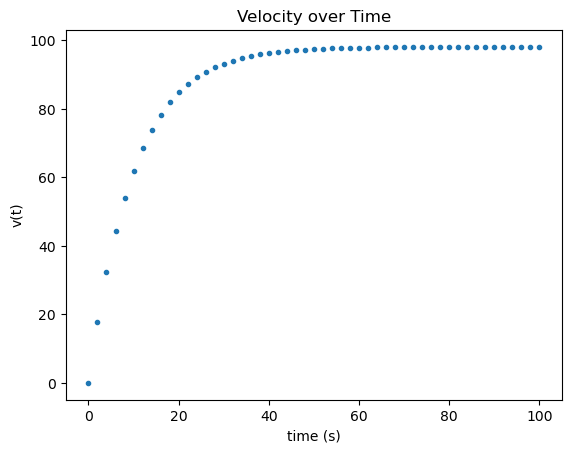

In [13]:
# plot the results
plt.plot(tpts, vpts, ".")
plt.title("Velocity over Time")
plt.xlabel("time (s)")
plt.ylabel("v(t)")
plt.show()

Imported matplotlib above to use for plots.

Graph is plotted using the plt.plot() function.

### Part 2: Euler Method

Calculate the solution for the same array of times using the Euler method instead. 

#### Step 1: 

Write two functions: `f(v)` that calculate the result of the differential equation for vertical, linear projectile motion, and `euler(t,h,v0,f)` that takes in an array $t$ of times in the same range as part 1 and using a defined $h$ value,initial conditions, and the differential equation returns an *array*. 

In [24]:
# function to find result
def f(v):
    return g - (b/m) * v

# function that uses euler
def euler(t,h,v0,f):
    # initialize velocity array for results
    vpts = np.zeros(len(t))

    # initialize constants
    g = 9.81
    b = 0.1 # drag coefficient
    m = 1.0 # mass in kg
    
    # utilizing the euler method
    for i in range(len(t)):
        vpts[i] = v0
        v0 += h * f(v0)
    
    return vpts


I began by defining Euler's Method within a function to be used when calculating velocities. All constants not inputted directly to the function were definied within the function.

Euler's Method involves iteration over the first couple of terms within the Taylor's Series, and provides a close estimation of the exact results.

#### Step 2

Calculate the array of velocities usig your `euler` function and make a plot of the results with the exact calculation on the **same** graph (put both results on the same graph here).

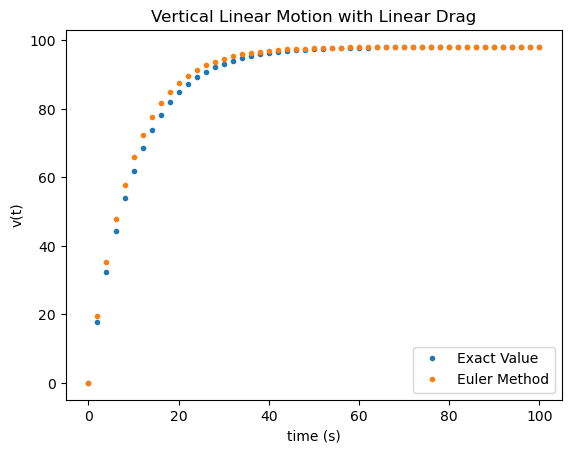

In [33]:
# initial contants/constraints
tstart = 0.0
tend = 100.0

# iteration constants, as defined in problem above
h = 2

# define time array
time = np.arange(tstart, tend+h, 2)

# calculate results using euler function
velocity = euler(time,h,v0,f)

# plot the results
plt.plot(tpts, vpts, ".", label="Exact Value") # exact
plt.plot(time, velocity, ".", label="Euler Method") # euler
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("v(t)")
plt.title("Vertical Linear Motion with Linear Drag")
plt.show()


Because the time is increasing by 2 for each step, h also has to increase by 2 because it serves as a 'time step' within the calculation process.

The function defined previously is used to plot the calculated valocities found using the Euler Method. The exact results shown in blue are taken from the first section of the lab, and is plotted alongside the Euler Method values for direct comparison.

The Euler Method is quite accurate and the valocities calculated are almost the same as the exact values, but it still lacks accuracy and differs slightly from the exact values. Within complex calculations, this small difference can create massive problems.

### Part 3: Fourth-order Runge-Kutta Method

Calculate the solution for the same array of times using the Runge-Kutta method instead. For this, define a function `RK4(t,h,v0,f)` that takes in an array of times, initial velocity, $h$, initial conditions, and differential equation function. 

Plot this as well as the exact and Euler solutions on the **same** graph as well. 

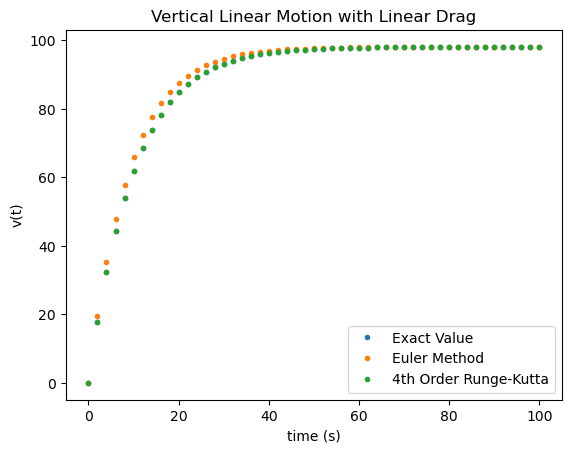

In [ ]:
# define Runge-Kutta method
def RK4(t,h,v0,f):
    # define array for velocity
    vrk4 = np.zeros(len(t))

    # initialize constants
    g = 9.81
    b = 0.1 # drag coefficient
    m = 1.0 # mass in kg

    # apply fourth order Runge-Kutta method
    for i in range(len(t)):
        vrk4[i] = v0
        k1 = h * f(v0)
        k2 = h * f(v0+0.5*k1)
        k3 = h * f(v0+0.5*k2)
        k4 = h * f(v0+k3)
        v0 += (k1 + 2*k2 + 2*k3 + k4)/6
    
    return vrk4


# initial contants/constraints
tstart = 0.0
tend = 100.0

# iteration constants, as defined in problem above
h = 2

# define time array
trk4 = np.arange(tstart, tend+h, 2)

# calculate results using euler function
vrk4 = RK4(time,h,v0,f)

# plot the results
plt.plot(tpts, vpts, ".", label="Exact Value") # exact
plt.plot(time, velocity, ".", label="Euler Method") # euler
plt.plot(trk4, vrk4, ".", label="4th Order Runge-Kutta") # 4th order runga-kutta

plt.legend()
plt.xlabel("time (s)")
plt.ylabel("v(t)")
plt.title("Vertical Linear Motion with Linear Drag")
plt.show()

I first defined a function that follows the Runge-Kutta methods by using its associated process of equations, as discussed in class. The function returned an array of velocities which was then used to plot the values found alongside the exact values and the values found previously by the Euler Method.

The 4th order Runge-Kutta method is so accurate you can no longer see the exact values on the plot because they line up so well!

### Part 4: Markdown comparision

What can you conclude about the results? Do they all agree? (Explain in a markdown cell below - you will need to change it to a markdown cell first)

The 4th order Runge-Kutta closely follows the actual velocity values calculated in part 1.

The values given by the Euler method are close to the actual values, but are still somewhat innacurate and needs more steps to fit properly.\
The values given by the 4th Order Runge-Kutta method fit the actual values much better, and is therefore a more accurate method to use when solving differential equations.

Physically, the velocity approches a terminal velocity of about 100 m/s in an exponential curve.

### Part 5: Adjust

Try using smaller and bigger time steps to see the effect of improving your approximations (Euler and/or Runge-Kutta). Explain your results and process in markdown. 

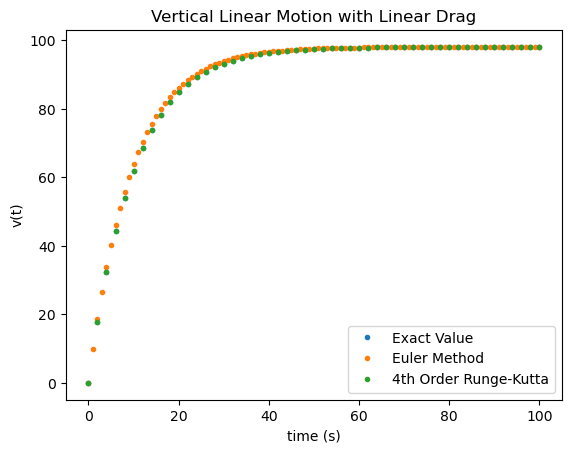

In [55]:
# trying to increase accuracy of Euler method
# initial contants/constraints
tstart = 0.0
tend = 100.0

# iteration constants, as defined in problem above
h = 1

# define time array
time = np.arange(tstart, tend+h, h)

# calculate results using euler function
velocity = euler(time,h,v0,f)

# plot the results
plt.plot(tpts, vpts, ".", label="Exact Value") # exact
plt.plot(time, velocity, ".", label="Euler Method") # euler
plt.plot(trk4, vrk4, ".", label="4th Order Runge-Kutta") # 4th order runga-kutta

plt.legend()
plt.xlabel("time (s)")
plt.ylabel("v(t)")
plt.title("Vertical Linear Motion with Linear Drag")
plt.show()

#### Explanation Markdown Cell: 

By making the time step h half as large, from 2 seconds to 1 second, the Euler method became much closer to the exact values and calculated Runge-Kutta for the velocity over time. This means the accuracy increased with the decrease in time step size.

Increasing the time step did the opposite, and the Euler method results became further from the exact valocity values.